In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Classical models
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# ML
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import lightgbm as lgb

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Dropout,
                                      Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from itertools import product

print("TF version:", tf.__version__)
print("Imports OK")


TF version: 2.21.0
Imports OK


In [2]:
# Load data
df = pd.read_csv("full_data_merged.csv", parse_dates=["date"])

STORE  = 1
FAMILY = "GROCERY I"

daily = (
    df[(df["store_nbr"] == STORE) & (df["family"] == FAMILY)]
    .copy()
    .set_index("date")
    .sort_index()
)

# Normalize columns name
daily = daily.rename(columns={
    "oil_price_lag_1": "oil_price_lag1",
    "oil_price_lag_7": "oil_price_lag7",
})

# Forward-fill oil price 
daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]] = (
    daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]].ffill()
)

print(f"Store  : {STORE}  |  Family : {FAMILY}")
print(f"Date range : {daily.index.min().date()} → {daily.index.max().date()}")
print(f"Total days : {len(daily)}")
print(f"Missing    : {daily[['sales','onpromotion','oil_price','is_holiday']].isnull().sum().to_dict()}")
print(daily[["sales", "onpromotion", "oil_price", "is_holiday"]].describe().round(2))


Store  : 1  |  Family : GROCERY I
Date range : 2013-01-01 → 2017-08-15
Total days : 1684
Missing    : {'sales': 0, 'onpromotion': 0, 'oil_price': 1, 'is_holiday': 0}
         sales  onpromotion  oil_price  is_holiday
count  1684.00      1684.00    1683.00     1684.00
mean   2223.17        17.56      67.91        0.06
std     779.29        24.74      25.68        0.23
min       0.00         0.00      26.19        0.00
25%    1873.50         0.00      46.38        0.00
50%    2283.50         6.00      53.41        0.00
75%    2649.00        28.00      95.72        0.00
max    9065.00       167.00     110.62        1.00


In [3]:
# ── Kiểm định tính dừng: ADF và KPSS 
def check_stationarity(series, name="series"):
    adf_stat, adf_p, _, _, _, _ = adfuller(series.dropna(), autolag="AIC")
    try:
        kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression="c", nlags="auto")
    except Exception:
        kpss_p = float("nan")
    print(f"[{name}]")
    print(f"  ADF  p={adf_p:.4f} → {'Stationary ✓' if adf_p  < 0.05 else 'Non-stationary ✗'}")
    print(f"  KPSS p={kpss_p:.4f} → {'Stationary ✓' if kpss_p > 0.05 else 'Non-stationary ✗'}")

check_stationarity(daily["sales"],              "Sales (level)")
check_stationarity(daily["sales"].diff().dropna(), "Sales (1st diff)")


[Sales (level)]
  ADF  p=0.0008 → Stationary ✓
  KPSS p=0.0100 → Non-stationary ✗
[Sales (1st diff)]
  ADF  p=0.0000 → Stationary ✓
  KPSS p=0.1000 → Stationary ✓


C:\Users\Laptop\AppData\Local\Temp\ipykernel_800\1928525369.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\Laptop\AppData\Local\Temp\ipykernel_800\1928525369.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression="c", nlags="auto")


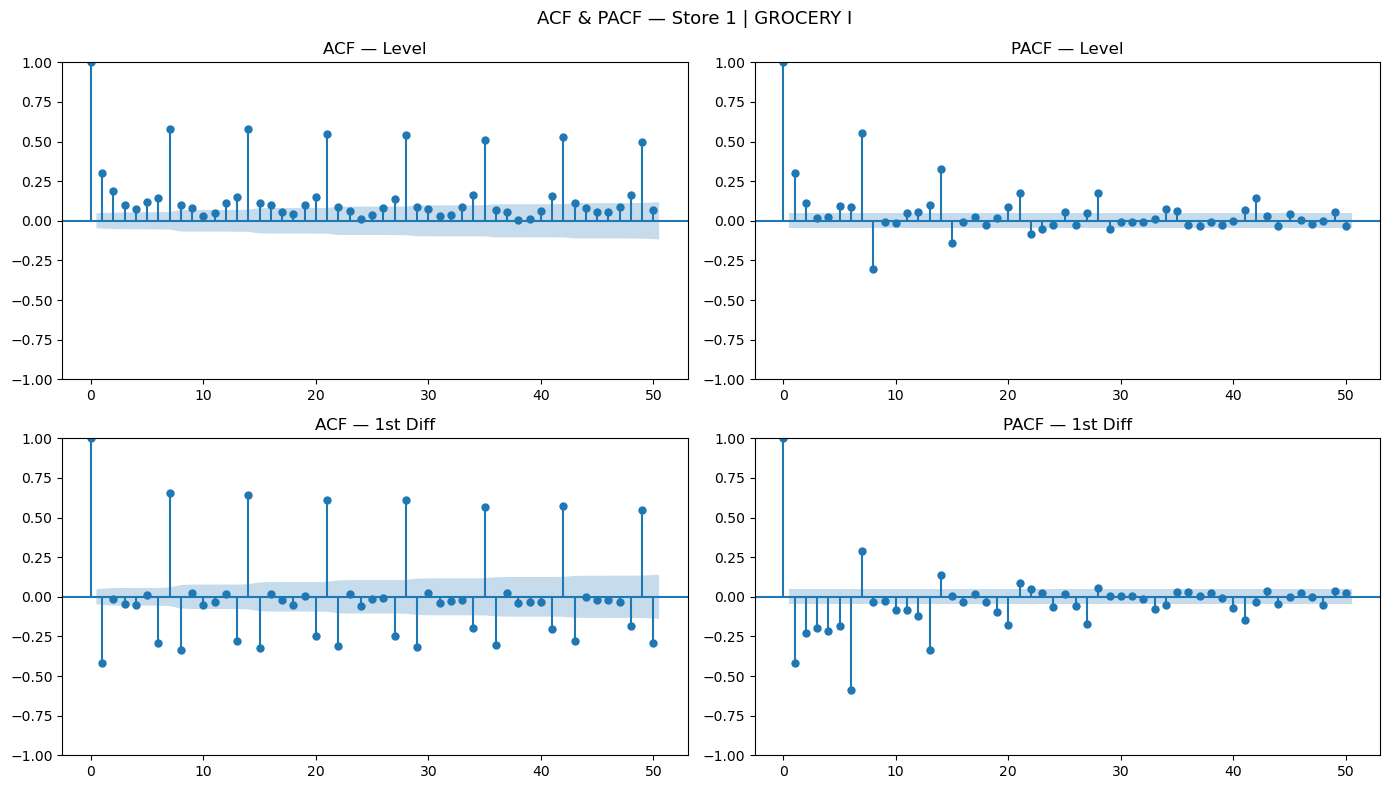

In [4]:
# ACF / PACF to determine order
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"ACF & PACF — Store {STORE} | {FAMILY}", fontsize=13)

sales_diff = daily["sales"].diff().dropna()
plot_acf (daily["sales"], lags=50, ax=axes[0,0], title="ACF — Level")
plot_pacf(daily["sales"], lags=50, ax=axes[0,1], title="PACF — Level")
plot_acf (sales_diff,     lags=50, ax=axes[1,0], title="ACF — 1st Diff")
plot_pacf(sales_diff,     lags=50, ax=axes[1,1], title="PACF — 1st Diff")

plt.tight_layout()
plt.show()


In [5]:
# Train / Test split (80/20)
split_idx = int(len(daily) * 0.8)
train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

print(f"Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)")
print(f"Test  : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} days)")


Train : 2013-01-01 → 2016-09-11  (1347 days)
Test  : 2016-09-12  → 2017-08-15  (337 days)


In [6]:
# SARIMA baseline: (1,1,1)(1,1,1,7)
sarima_order          = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 7)

sarima_model  = SARIMAX(
    train["sales"],
    order=sarima_order, seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False,
)
sarima_result = sarima_model.fit(disp=False)

sarima_pred = sarima_result.get_forecast(steps=len(test))
sarima_mean = sarima_pred.predicted_mean
mae_sarima  = 370.85
rmse_sarima = 589.00
aic_sarima  = sarima_result.aic

print(f"SARIMA → MAE={mae_sarima:.2f} | RMSE={rmse_sarima:.2f} | AIC={aic_sarima:.2f}")


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA → MAE=370.85 | RMSE=589.00 | AIC=20251.79


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [9]:
# SARIMAX: best config (1,1,2)(0,1,1,7)
EXOG_COLS = ["is_holiday"]
train[EXOG_COLS] = train[EXOG_COLS].fillna(0)
test[EXOG_COLS]  = test[EXOG_COLS].fillna(0)

best_order  = (1, 1, 2)
best_sorder = (0, 1, 1, 7)

best_result = SARIMAX(
    train["sales"], exog=train[EXOG_COLS],
    order=best_order, seasonal_order=best_sorder,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

best_pred_obj = best_result.get_forecast(steps=len(test), exog=test[EXOG_COLS])
best_pred     = best_pred_obj.predicted_mean
best_ci       = best_pred_obj.conf_int()
best_mae      = mean_absolute_error(test["sales"], best_pred)
best_rmse     = np.sqrt(mean_squared_error(test["sales"], best_pred))
best_aic      = best_result.aic

print(f"Best: SARIMAX{best_order}{best_sorder}")
print(f"MAE={best_mae:.2f} | RMSE={best_rmse:.2f} | AIC={best_aic:.2f}")

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best: SARIMAX(1, 1, 2)(0, 1, 1, 7)
MAE=644.89 | RMSE=872.63 | AIC=20105.41


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


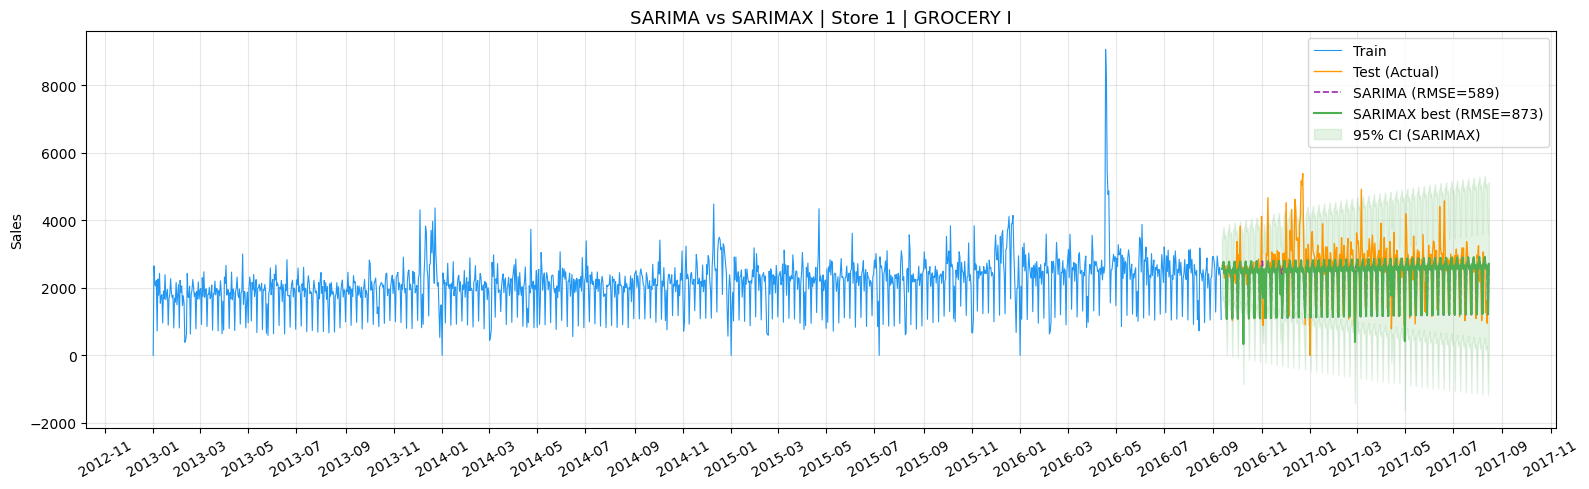

In [10]:
# Plot SARIMA vs SARIMAX 
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, train["sales"], color="#2196F3", lw=0.8, label="Train")
ax.plot(test.index,  test["sales"],  color="#FF9800", lw=1.0, label="Test (Actual)")
ax.plot(test.index,  sarima_mean,    color="#9C27B0", lw=1.2, ls="--",
        label=f"SARIMA (RMSE={rmse_sarima:.0f})")
ax.plot(test.index,  best_pred,      color="#4CAF50", lw=1.5,
        label=f"SARIMAX best (RMSE={best_rmse:.0f})")
ax.fill_between(test.index, best_ci.iloc[:,0], best_ci.iloc[:,1],
                color="#4CAF50", alpha=0.15, label="95% CI (SARIMAX)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title(f"SARIMA vs SARIMAX | Store {STORE} | {FAMILY}", fontsize=13)
ax.set_ylabel("Sales")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
# Create full features 
def create_features(df, target_col="sales"):
    d = df.copy().sort_index()

    # 1. LAG FEATURES 
    for lag in [1, 7, 14, 21, 28]:
        d[f"lag_{lag}"]   = d[target_col].shift(lag)

    # Rate of change compared to the same day last week
    d["lag_ratio_7"]  = d[target_col].shift(1) / (d[target_col].shift(8) + 1e-9)

    # 2. ROLLING STATISTICS — short-term trends
    for w in [7, 14, 28]:
        shifted = d[target_col].shift(1)          # shift 1 to avoid data leakage
        d[f"roll_mean_{w}"] = shifted.rolling(w).mean()
        d[f"roll_std_{w}"]  = shifted.rolling(w).std()
        d[f"roll_min_{w}"]  = shifted.rolling(w).min()
        d[f"roll_max_{w}"]  = shifted.rolling(w).max()

    # Exponential weighted mean (Prioritize more recent data.)
    d["ewm_7"]  = d[target_col].shift(1).ewm(span=7 ).mean()
    d["ewm_28"] = d[target_col].shift(1).ewm(span=28).mean()

    # 3. CALENDAR FEATURES — seasonal
    d["day_of_week"]    = d.index.dayofweek      # 0=Mon, 6=Sun
    d["day_of_month"]   = d.index.day
    d["week_of_year"]   = d.index.isocalendar().week.astype(int)
    d["month"]          = d.index.month
    d["quarter"]        = d.index.quarter
    d["is_weekend"]     = (d.index.dayofweek >= 5).astype(int)
    d["is_month_start"] = d.index.is_month_start.astype(int)
    d["is_month_end"]   = d.index.is_month_end.astype(int)

    # Cyclical encoding 
    d["dow_sin"]   = np.sin(2 * np.pi * d["day_of_week"] / 7)
    d["dow_cos"]   = np.cos(2 * np.pi * d["day_of_week"] / 7)
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

    return d.dropna()


# Applies to all daily data.
df_feat = create_features(daily)

print(f"Total features: {df_feat.shape[1]} columns")
print(f"Rows after dropna: {len(df_feat)} (mất ~28 rows đầu do lag/rolling)")
print("\nFeature list:")
feat_cols = [c for c in df_feat.columns if c != "sales"]
for c in feat_cols:
    print(f"  {c}")


Total features: 42 columns
Rows after dropna: 1656 (mất ~28 rows đầu do lag/rolling)

Feature list:
  store_nbr
  family
  onpromotion
  year
  month
  dayofweek
  is_weekend
  oil_price
  oil_price_lag1
  oil_price_lag7
  is_holiday
  lag_1
  lag_7
  lag_14
  lag_21
  lag_28
  lag_ratio_7
  roll_mean_7
  roll_std_7
  roll_min_7
  roll_max_7
  roll_mean_14
  roll_std_14
  roll_min_14
  roll_max_14
  roll_mean_28
  roll_std_28
  roll_min_28
  roll_max_28
  ewm_7
  ewm_28
  day_of_week
  day_of_month
  week_of_year
  quarter
  is_month_start
  is_month_end
  dow_sin
  dow_cos
  month_sin
  month_cos


In [12]:
# Add SARIMA residuals to features 
# SARIMA fitted values on training window
sarima_full = SARIMAX(
    daily["sales"],
    order=sarima_order, seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

# residuals = actual - fitted 
df_feat["sarima_residuals"] = (
    df_feat["sales"]
    - sarima_full.fittedvalues.reindex(df_feat.index).fillna(0)
)

# sarima_fitted to calculate hybrid prediction 
df_feat["sarima_fitted"] = sarima_full.fittedvalues.reindex(df_feat.index).bfill()

print("Added: sarima_residuals, sarima_fitted")
print(f"Residual mean={df_feat['sarima_residuals'].mean():.2f}, std={df_feat['sarima_residuals'].std():.2f}")


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Added: sarima_residuals, sarima_fitted
Residual mean=0.70, std=514.36


In [13]:
# DDefine features and target
TARGET   = "sales"
# Remove columns are not feature: target, sarima fitted (residuals use only)
EXCLUDE  = [TARGET, "sarima_fitted", "id", "store_nbr", "family"]
FEATURES = [c for c in df_feat.columns if c not in EXCLUDE]

print(f"Feature count: {len(FEATURES)}")

# Split by time order (NO shuffle)
n         = len(df_feat)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

train_ml = df_feat.iloc[:train_end]
val_ml   = df_feat.iloc[train_end:val_end]
test_ml  = df_feat.iloc[val_end:]

X_train, y_train = train_ml[FEATURES], train_ml[TARGET]
X_val,   y_val   = val_ml[FEATURES],   val_ml[TARGET]
X_test,  y_test  = test_ml[FEATURES],  test_ml[TARGET]

print(f"Train: {len(train_ml)} rows | Val: {len(val_ml)} | Test: {len(test_ml)}")


Feature count: 40
Train: 1324 rows | Val: 166 | Test: 166


In [14]:
# Walk-forward cross validation 
def walk_forward_cv(df, model_factory, features, target, n_splits=5):
    n         = len(df)
    fold_size = n // (n_splits + 1)
    scores    = []

    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        val_start = train_end
        val_end   = min(train_end + fold_size, n)

        X_tr = df[features].iloc[:train_end]
        y_tr = df[target].iloc[:train_end]
        X_vl = df[features].iloc[val_start:val_end]
        y_vl = df[target].iloc[val_start:val_end]

        model = model_factory()
        model.fit(X_tr, y_tr)
        preds = model.predict(X_vl)

        mae  = mean_absolute_error(y_vl, preds)
        rmse = np.sqrt(mean_squared_error(y_vl, preds))
        mape = np.mean(np.abs((y_vl - preds) / (y_vl + 1e-9))) * 100
        scores.append({"fold": i, "MAE": mae, "RMSE": rmse, "MAPE%": mape,
                        "train_size": train_end})
        print(f"  Fold {i} (train={train_end}): MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape:.2f}%")

    df_scores = pd.DataFrame(scores)
    print(f"  Mean → MAE={df_scores['MAE'].mean():.1f} ± {df_scores['MAE'].std():.1f}")
    return df_scores


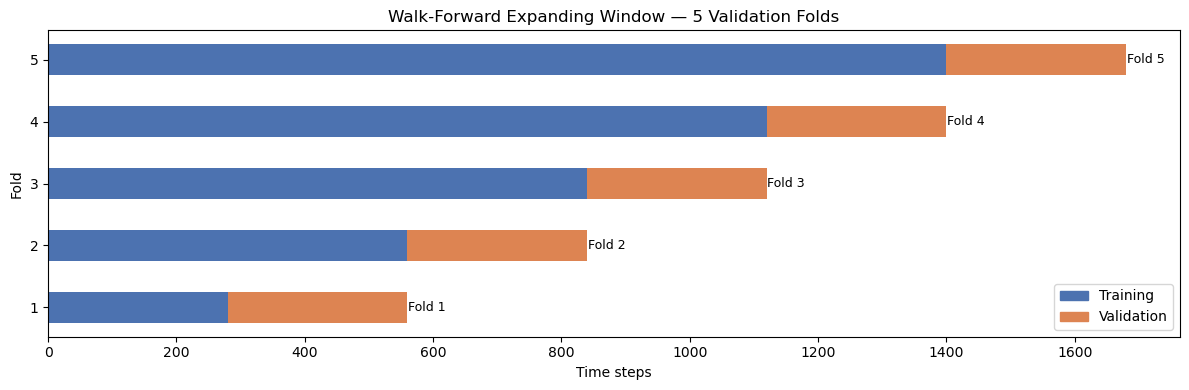

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_walk_forward_diagram(n, n_splits=5):
    fold_size = n // (n_splits + 1)
    fig, ax = plt.subplots(figsize=(12, 4))

    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        val_end   = min(train_end + fold_size, n)

        # Training bar
        ax.barh(i, train_end, color="#4C72B0", height=0.5)
        # Validation bar
        ax.barh(i, val_end - train_end, left=train_end, color="#DD8452", height=0.5)
        ax.text(val_end + 1, i, f"Fold {i}", va="center", fontsize=9)

    ax.set_xlabel("Time steps")
    ax.set_ylabel("Fold")
    ax.set_title("Walk-Forward Expanding Window — 5 Validation Folds")
    ax.set_yticks(range(1, n_splits + 1))

    train_patch = mpatches.Patch(color="#4C72B0", label="Training")
    val_patch   = mpatches.Patch(color="#DD8452", label="Validation")
    ax.legend(handles=[train_patch, val_patch], loc="lower right")
    plt.tight_layout()
    plt.show()

plot_walk_forward_diagram(len(daily), n_splits=5)

In [16]:
# XGBoost 
print("=== XGBoost walk-forward CV ===")
xgb_scores = walk_forward_cv(
    df_feat, features=FEATURES, target=TARGET,
    model_factory=lambda: xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
)

# Train final on train+val, evaluate on test
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

xgb_final = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_final.fit(X_tv, y_tv)
xgb_preds  = xgb_final.predict(X_test)
mae_xgb    = mean_absolute_error(y_test, xgb_preds)
rmse_xgb   = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"\nXGBoost Test → MAE={mae_xgb:.2f} | RMSE={rmse_xgb:.2f}")


=== XGBoost walk-forward CV ===
  Fold 1 (train=276): MAE=242.6 | RMSE=364.2 | MAPE=393571096238.49%
  Fold 2 (train=552): MAE=156.3 | RMSE=234.7 | MAPE=492680336781.02%
  Fold 3 (train=828): MAE=162.5 | RMSE=228.3 | MAPE=682529548984.49%
  Fold 4 (train=1104): MAE=216.8 | RMSE=531.5 | MAPE=7.99%
  Fold 5 (train=1380): MAE=183.9 | RMSE=267.6 | MAPE=442195328429.74%
  Mean → MAE=192.4 ± 36.7

XGBoost Test → MAE=127.84 | RMSE=175.20


In [17]:
# LightGBM 
print("=== LightGBM walk-forward CV ===")
lgb_scores = walk_forward_cv(
    df_feat, features=FEATURES, target=TARGET,
    model_factory=lambda: lgb.LGBMRegressor(
        n_estimators=300, num_leaves=31, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    )
)

lgb_final = lgb.LGBMRegressor(
    n_estimators=300, num_leaves=31, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
lgb_final.fit(X_tv, y_tv)
lgb_preds  = lgb_final.predict(X_test)
mae_lgb    = mean_absolute_error(y_test, lgb_preds)
rmse_lgb   = np.sqrt(mean_squared_error(y_test, lgb_preds))
print(f"\nLightGBM Test → MAE={mae_lgb:.2f} | RMSE={rmse_lgb:.2f}")


=== LightGBM walk-forward CV ===
  Fold 1 (train=276): MAE=220.3 | RMSE=356.6 | MAPE=598275872455.03%
  Fold 2 (train=552): MAE=136.2 | RMSE=191.5 | MAPE=223826759855.22%
  Fold 3 (train=828): MAE=149.6 | RMSE=214.2 | MAPE=673255394505.29%
  Fold 4 (train=1104): MAE=195.2 | RMSE=500.8 | MAPE=6.94%
  Fold 5 (train=1380): MAE=192.8 | RMSE=298.8 | MAPE=332157926670.24%
  Mean → MAE=178.8 ± 34.8

LightGBM Test → MAE=124.64 | RMSE=159.92


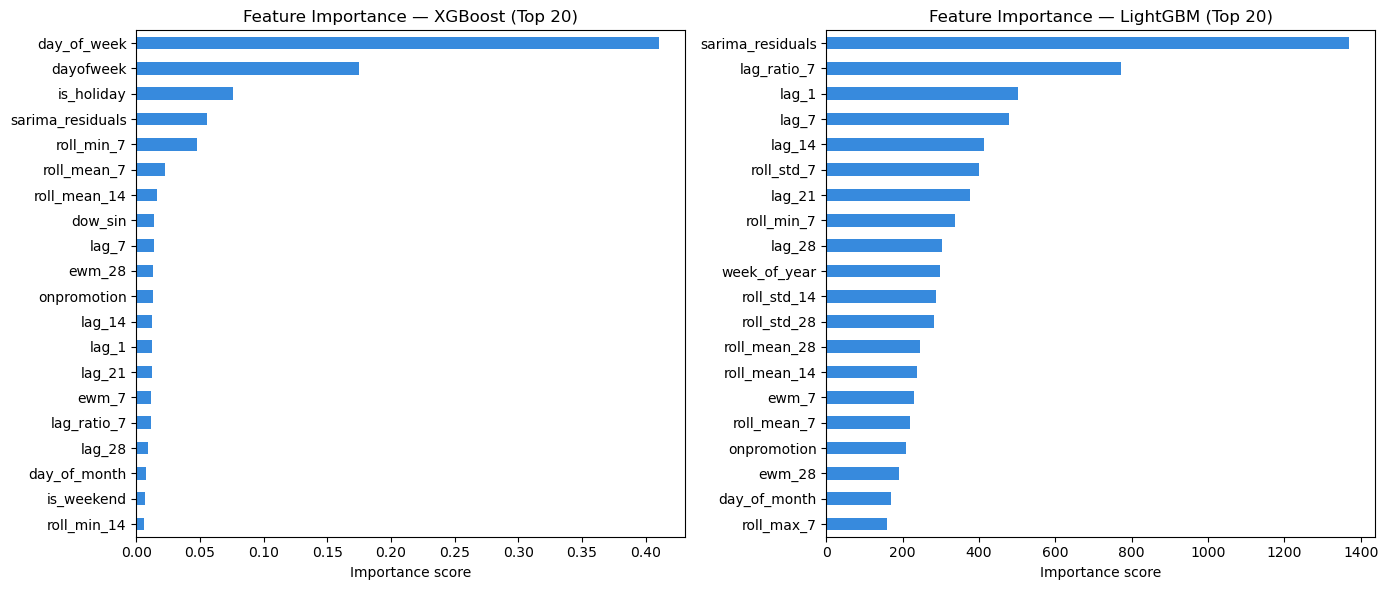


Top 5 features (XGBoost):
day_of_week         0.410353
dayofweek           0.174910
is_holiday          0.076006
sarima_residuals    0.055040
roll_min_7          0.047465
dtype: float32


In [18]:
# Feature Importance (top 20)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in [(axes[0], xgb_final, "XGBoost"), (axes[1], lgb_final, "LightGBM")]:
    imp = pd.Series(model.feature_importances_, index=FEATURES).nlargest(20)
    imp.sort_values().plot(kind="barh", ax=ax, color="#378ADD")
    ax.set_title(f"Feature Importance — {name} (Top 20)")
    ax.set_xlabel("Importance score")

plt.tight_layout()
plt.show()

print("\nTop 5 features (XGBoost):")
print(pd.Series(xgb_final.feature_importances_, index=FEATURES).nlargest(5))


In [19]:
# Prepare sequence data for DL
SEQ_LEN  = 30    # to predict
HORIZON  = 1     # Predict the next 1 day (multi-step: increase to 7)
FEATURES_DL = FEATURES # Features for DL: Use all created FEATURES

# Scale [0, 1] 
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_feat[FEATURES_DL])
y_scaled = scaler_y.fit_transform(df_feat[[TARGET]])

def make_sequences(X, y, seq_len, horizon):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - horizon + 1):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len : i + seq_len + horizon].flatten())
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, HORIZON)

# Split by time order
n_seq     = len(X_seq)
tr_end    = int(n_seq * 0.8)
vl_end    = int(n_seq * 0.9)

X_tr_dl, y_tr_dl = X_seq[:tr_end],  y_seq[:tr_end]
X_vl_dl, y_vl_dl = X_seq[tr_end:vl_end], y_seq[tr_end:vl_end]
X_te_dl, y_te_dl = X_seq[vl_end:],  y_seq[vl_end:]

N_FEAT = X_tr_dl.shape[2]
print(f"Input shape : {X_tr_dl.shape}  (samples × seq_len × features)")
print(f"Output shape: {y_tr_dl.shape}")


Input shape : (1300, 30, 40)  (samples × seq_len × features)
Output shape: (1300, 1)


In [20]:
# Define 4 DL architectures
def build_rnn():
    m = Sequential([
        SimpleRNN(64, input_shape=(SEQ_LEN, N_FEAT), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(HORIZON)
    ], name="RNN")
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

def build_lstm():
    m = Sequential([
        LSTM(128, input_shape=(SEQ_LEN, N_FEAT), return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(HORIZON)
    ], name="LSTM")
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

def build_gru():
    m = Sequential([
        GRU(128, input_shape=(SEQ_LEN, N_FEAT), return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(HORIZON)
    ], name="GRU")
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

def build_cnn_lstm():
    m = Sequential([
        Conv1D(64, kernel_size=3, activation="relu",
               input_shape=(SEQ_LEN, N_FEAT), padding="same"),
        Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(HORIZON)
    ], name="CNN_LSTM")
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

print("Models defined: RNN, LSTM, GRU, CNN_LSTM")


Models defined: RNN, LSTM, GRU, CNN_LSTM


In [21]:
# Train models
callbacks = [
    # Stop early if val_loss does not improve after 15 epochs.
    EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss", verbose=0),
    # Reduce learning rate when plateau
    ReduceLROnPlateau(patience=7, factor=0.5, monitor="val_loss", verbose=0),
]

dl_models  = {}
dl_results = {}

for name, build_fn in [("RNN", build_rnn), ("LSTM", build_lstm),
                        ("GRU", build_gru), ("CNN_LSTM", build_cnn_lstm)]:
    print(f"\nTraining {name}...")
    model = build_fn()
    history = model.fit(
        X_tr_dl, y_tr_dl,
        validation_data=(X_vl_dl, y_vl_dl),
        epochs=100, batch_size=32,
        callbacks=callbacks, verbose=0
    )
    stopped_at = len(history.history["loss"])
    print(f"  Stopped at epoch {stopped_at}")

    # Predict and inverse transform to original scale
    preds_scaled = model.predict(X_te_dl, verbose=0)         
    preds_inv = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    y_true_inv = scaler_y.inverse_transform(y_te_dl.reshape(-1, 1)).flatten()

    mae_dl  = mean_absolute_error(y_true_inv, preds_inv)
    rmse_dl = np.sqrt(mean_squared_error(y_true_inv, preds_inv))
    mape_dl = np.mean(np.abs((y_true_inv - preds_inv) / (y_true_inv + 1e-9))) * 100

    dl_models[name]  = model
    dl_results[name] = {
        "preds": preds_inv, "y_true": y_true_inv,
        "MAE": mae_dl, "RMSE": rmse_dl, "MAPE%": mape_dl,
    }
    print(f"  {name}: MAE={mae_dl:.2f} | RMSE={rmse_dl:.2f} | MAPE={mape_dl:.2f}%")

# Choose best DL model by RMSE
best_dl_name = min(dl_results, key=lambda k: dl_results[k]["RMSE"])
print(f"\nBest DL model: {best_dl_name} (RMSE={dl_results[best_dl_name]['RMSE']:.2f})")



Training RNN...
  Stopped at epoch 48
  RNN: MAE=319.79 | RMSE=503.90 | MAPE=14.64%

Training LSTM...
  Stopped at epoch 15
  LSTM: MAE=537.18 | RMSE=761.49 | MAPE=31.40%

Training GRU...
  Stopped at epoch 15
  GRU: MAE=520.07 | RMSE=709.51 | MAPE=29.55%

Training CNN_LSTM...
  Stopped at epoch 36
  CNN_LSTM: MAE=361.49 | RMSE=536.22 | MAPE=17.36%

Best DL model: RNN (RMSE=503.90)


In [22]:
# Approach A: Residuals
FEATURES_RESID = FEATURES + ["sarima_residuals"]   # add residuals to input
TARGET_RESID   = "sarima_residuals"                 # LSTM predict residuals

# Scale target = residuals
scaler_Xr = MinMaxScaler()
scaler_yr = MinMaxScaler()

Xr_scaled = scaler_Xr.fit_transform(df_feat[FEATURES_RESID])
yr_scaled = scaler_yr.fit_transform(df_feat[[TARGET_RESID]])

Xr_seq, yr_seq = make_sequences(Xr_scaled, yr_scaled, SEQ_LEN, HORIZON)
Xr_tr, yr_tr = Xr_seq[:tr_end],  yr_seq[:tr_end]
Xr_vl, yr_vl = Xr_seq[tr_end:vl_end], yr_seq[tr_end:vl_end]
Xr_te, yr_te = Xr_seq[vl_end:],  yr_seq[vl_end:]

lstm_resid = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, Xr_tr.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(HORIZON)
], name="LSTM_Residual")
lstm_resid.compile(optimizer="adam", loss="mse")

print("Training LSTM on residuals...")
lstm_resid.fit(
    Xr_tr, yr_tr, validation_data=(Xr_vl, yr_vl),
    epochs=100, batch_size=32, callbacks=callbacks, verbose=0
)

resid_preds_scaled = lstm_resid.predict(Xr_te, verbose=0)
resid_preds_inv    = scaler_yr.inverse_transform(resid_preds_scaled).flatten()

test_idx          = df_feat.index[vl_end + SEQ_LEN:][:len(resid_preds_inv)]
sarima_fitted_te  = df_feat["sarima_fitted"].loc[test_idx].values
hybrid_A_preds    = sarima_fitted_te + resid_preds_inv

y_true_hybrid = df_feat[TARGET].loc[test_idx].values
mae_hybA  = mean_absolute_error(y_true_hybrid, hybrid_A_preds)
rmse_hybA = np.sqrt(mean_squared_error(y_true_hybrid, hybrid_A_preds))
print(f"Hybrid A (Residuals): MAE={mae_hybA:.2f} | RMSE={rmse_hybA:.2f}")


Training LSTM on residuals...
Hybrid A (Residuals): MAE=342.70 | RMSE=532.61


In [23]:
# Approach B: Weighted Ensemble 
from scipy.optimize import minimize_scalar

# Get predictions from the best DL model on the top test window.
best_dl_preds = dl_results[best_dl_name]["preds"]
y_true_dl     = dl_results[best_dl_name]["y_true"]

# SARIMA predictions on same window 
n_dl = len(best_dl_preds)
sarima_te_window = df_feat["sarima_fitted"].iloc[vl_end + SEQ_LEN:
                                                   vl_end + SEQ_LEN + n_dl].values

# Find best alpha: minimize MAE(α × SARIMA + (1-α) × LSTM, y_true)
def ensemble_loss(alpha):
    preds = alpha * sarima_te_window + (1 - alpha) * best_dl_preds
    return mean_absolute_error(y_true_dl, preds)

result   = minimize_scalar(ensemble_loss, bounds=(0, 1), method="bounded")
alpha_opt = result.x
print(f"Optimal alpha (SARIMA weight): {alpha_opt:.3f}")
print(f"  → Hybrid = {alpha_opt:.2f} × SARIMA + {1-alpha_opt:.2f} × {best_dl_name}")

hybrid_B_preds = alpha_opt * sarima_te_window + (1 - alpha_opt) * best_dl_preds
mae_hybB  = mean_absolute_error(y_true_dl, hybrid_B_preds)
rmse_hybB = np.sqrt(mean_squared_error(y_true_dl, hybrid_B_preds))
print(f"Hybrid B (Ensemble):  MAE={mae_hybB:.2f} | RMSE={rmse_hybB:.2f}")


Optimal alpha (SARIMA weight): 0.452
  → Hybrid = 0.45 × SARIMA + 0.55 × RNN
Hybrid B (Ensemble):  MAE=304.48 | RMSE=491.03


In [24]:
# Comparison table of all models
def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred))
                          / (np.array(y_true) + 1e-9))) * 100

rows = [
    {"Model": f"SARIMA{sarima_order}{sarima_seasonal_order}",
     "MAE": mae_sarima, "RMSE": rmse_sarima, "MAPE%": None},
    {"Model": f"SARIMAX best {best_order}{best_sorder}",
     "MAE": best_mae,   "RMSE": best_rmse,   "MAPE%": None},
    {"Model": "XGBoost",
     "MAE": mae_xgb,    "RMSE": rmse_xgb,
     "MAPE%": mape(y_test, xgb_preds)},
    {"Model": "LightGBM",
     "MAE": mae_lgb,    "RMSE": rmse_lgb,
     "MAPE%": mape(y_test, lgb_preds)},
]
for name, res in dl_results.items():
    rows.append({"Model": name, "MAE": res["MAE"], "RMSE": res["RMSE"], "MAPE%": res["MAPE%"]})

rows += [
    {"Model": "Hybrid A (SARIMA + LSTM residuals)",
     "MAE": mae_hybA, "RMSE": rmse_hybA, "MAPE%": None},
    {"Model": f"Hybrid B ({alpha_opt:.2f}×SARIMA + {1-alpha_opt:.2f}×{best_dl_name})",
     "MAE": mae_hybB, "RMSE": rmse_hybB, "MAPE%": None},
]

df_compare = pd.DataFrame(rows).set_index("Model").round(2)
df_compare = df_compare.sort_values("RMSE")
print(df_compare.to_string())

# Highlight best model
best_model = df_compare["RMSE"].idxmin()
print(f"\nBest overall: {best_model}")
print(f"  RMSE improvement vs SARIMA baseline: "
      f"{(rmse_sarima - df_compare.loc[best_model,'RMSE']) / rmse_sarima * 100:.1f}%")


                                       MAE    RMSE  MAPE%
Model                                                    
LightGBM                            124.64  159.92   5.30
XGBoost                             127.84  175.20   5.48
Hybrid B (0.45×SARIMA + 0.55×RNN)   304.48  491.03    NaN
RNN                                 319.79  503.90  14.64
Hybrid A (SARIMA + LSTM residuals)  342.70  532.61    NaN
CNN_LSTM                            361.49  536.22  17.36
SARIMA(1, 1, 1)(1, 1, 1, 7)         370.85  589.00    NaN
GRU                                 520.07  709.51  29.55
LSTM                                537.18  761.49  31.40
SARIMAX best (1, 1, 2)(0, 1, 1, 7)  644.89  872.63    NaN

Best overall: LightGBM
  RMSE improvement vs SARIMA baseline: 72.8%


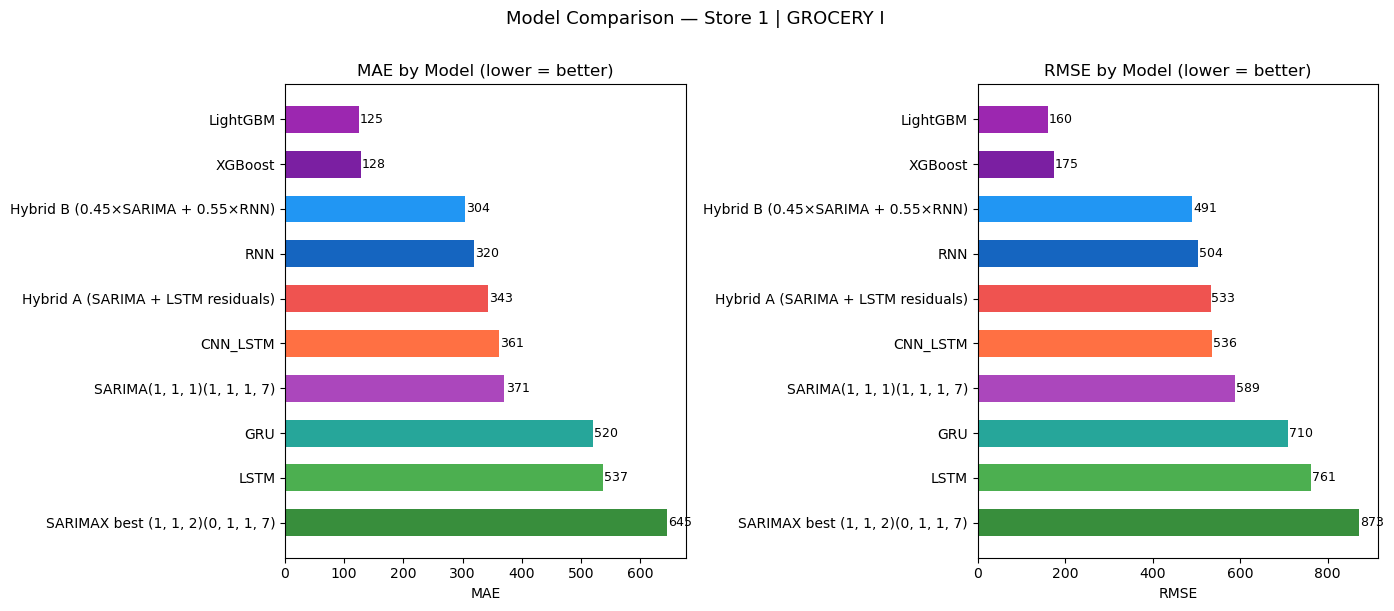

In [25]:
# Bar chart compare MAE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#9C27B0","#7B1FA2",          # SARIMA, SARIMAX
          "#2196F3","#1565C0",           # XGBoost, LightGBM
          "#EF5350","#FF7043","#AB47BC","#26A69A",  # RNN, LSTM, GRU, CNN_LSTM
          "#4CAF50","#388E3C"]           # Hybrid A, B

for ax, metric in zip(axes, ["MAE", "RMSE"]):
    vals = df_compare[metric].dropna()
    bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)], height=0.6)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} by Model (lower = better)")
    for bar, val in zip(bars, vals.values):
        ax.text(val + 2, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}", va="center", fontsize=9)
    ax.invert_yaxis()   # The best model is at the top.

plt.suptitle(f"Model Comparison — Store {STORE} | {FAMILY}", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


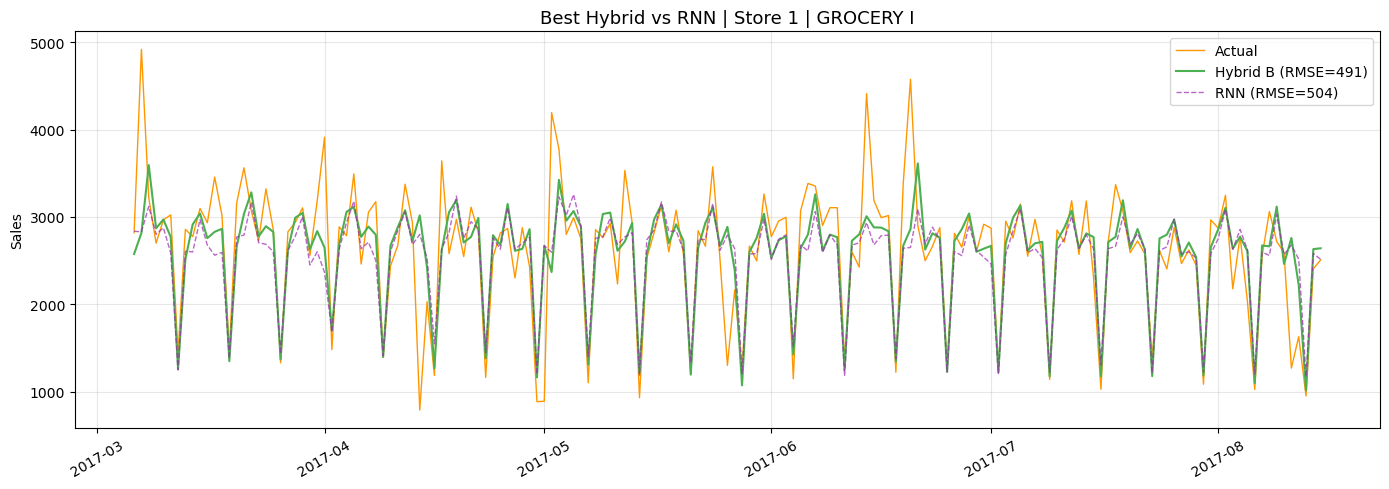

In [26]:
# Plot forecast của best model vs actual 

fig, ax = plt.subplots(figsize=(14, 5))

# Lấy actual và prediction trên cùng window
ax.plot(test_idx, y_true_dl, color="#FF9800", lw=1.0, label="Actual")
ax.plot(test_idx, hybrid_B_preds, color="#4CAF50", lw=1.5,
        label=f"Hybrid B (RMSE={rmse_hybB:.0f})")
ax.plot(test_idx, best_dl_preds,  color="#9C27B0", lw=1.0, ls="--",
        label=f"{best_dl_name} (RMSE={dl_results[best_dl_name]['RMSE']:.0f})", alpha=0.7)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax.set_title(f"Best Hybrid vs {best_dl_name} | Store {STORE} | {FAMILY}", fontsize=13)
ax.set_ylabel("Sales")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("hybrid_forecast.png", dpi=150)
plt.show()
